# DataSprint 2026 — Financial Status Prediction (Kenya FinAccess 2024)

### Strathmore Data Community × iLab Africa

**Goal:** Predict whether a Kenyan adult's `financial_status` has *Improved*, *Stayed the same*, or *Worsened* compared to the previous year, and identify the key drivers behind financial deterioration.

**Guiding question:** Which factors most strongly predict financial deterioration among Kenyan adults, and what should policymakers, banks, or NGOs prioritise to improve financial wellbeing?

This notebook follows the CRISP-DM framework, scoped to the hackathon's focus areas:

| Phase | Section |
|---|---|
| 1 | Setup & Data Loading |
| 2 | Data Understanding (Inspection) |
| 3 | Exploratory Data Analysis (EDA) |
| 4 | Data Cleaning & Preprocessing |
| 5 | Feature Engineering |
| 6 | Train/Test Split |
| 7 | Modelling |
| 8 | Evaluation |
| 9 | Interpretation — Key Drivers |
| 10 | Conclusions & Recommendations |

> **Reminder:** We evaluate using **Weighted F1-score**, not accuracy — `financial_status` is imbalanced (Worsened 52.6%, Stayed the same 26.9%, Improved 20.5%).


## Phase 1 — Setup & Data Loading

Import libraries and load the curated dataset (`finaccess2024_datasprint.csv`).

If you're running this in **Google Colab**, upload `finaccess2024_datasprint.csv` to the Colab session (or mount Google Drive) before running the cell below.


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (f1_score, classification_report,
                              confusion_matrix, ConfusionMatrixDisplay)

# Plot styling
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (8, 5)

RANDOM_STATE = 42

In [2]:
# --- Upload the data from your laptop ---
from google.colab import files
uploaded = files.upload()  # select your finaccess2024_datasprint file (.csv or .xlsx)

filename = list(uploaded.keys())[0]

if filename.endswith('.csv'):
    df = pd.read_csv(filename)
else:
    df = pd.read_excel(filename)

print("Shape:", df.shape)
df.head()

Saving finaccess2024_datasprint.xlsx to finaccess2024_datasprint.xlsx
Shape: (20871, 28)


,county,location_type,Sex,Age,household_size,education_level,marital_status,monthly_income,Savings_formal,Savings_informal,...,nfhi_11,nfhi_12,nfhi_13,accessto_13k_1month,not_difficult,financial_status,fl_score,prodsum1,barriers_bank,has_disability
0,Garissa,Urban,Female,26-35,5,Completed technical training after secondary s...,Married/Living with partner,30000,Non-usage,Non-usage,...,Yes,Yes,Yes,Yes,No,Stayed the same,All correct,3,NaN,Without Disability
1,Garissa,Urban,Female,Above 55,11,"""None """,Married/Living with partner,10000,Non-usage,Non-usage,...,No,No,Yes,No,No,Worsened,Two correct,1,Affordability,Without Disability
2,Busia,Urban,Female,26-35,2,"""Primary completed""",Divorced/separated,3000,Usage,Usage,...,Yes,No,No,No,No,Improved,All correct,5,Affordability,Without Disability
3,Kiambu,Urban,Male,18-25,1,"""Some secondary""",Single/Never Married,10000,Usage,Non-usage,...,No,No,No,Yes,No,Improved,All correct,4,Affordability,Without Disability
4,Murang'a,Urban,Female,18-25,1,Some technical training after secondary school,Single/Never Married,10000,Usage,Non-usage,...,Yes,Yes,Yes,Yes,Yes,Improved,All correct,5,NaN,Without Disability


# Phase 2 — Data Understanding

Before changing anything, let's understand what we're working with:
- Shape, column types
- Missing values
- Target variable distribution
- Sanity checks (duplicates, unexpected values)


In [3]:
# Shape and data types
print("Rows, Columns:", df.shape)
df.dtypes

Rows, Columns: (20871, 28)


,0
county,object
location_type,object
Sex,object
Age,object
household_size,int64
education_level,object
marital_status,object
monthly_income,int64
Savings_formal,object
Savings_informal,object


In [4]:
# Missing values
missing = df.isnull().sum()
missing = missing[missing > 0]
print("Columns with missing values:")
print(missing)
print(f"\n'barriers_bank' missing %: {df['barriers_bank'].isnull().mean()*100:.1f}%")

Columns with missing values:
barriers_bank    5734
dtype: int64

'barriers_bank' missing %: 27.5%


In [5]:
# Duplicate rows check
print("Duplicate rows:", df.duplicated().sum())

Duplicate rows: 5


In [6]:
# Target variable distribution
print(df['financial_status'].value_counts())
print(df['financial_status'].value_counts(normalize=True) * 100)

financial_status
Worsened           10981
Stayed the same     5609
Improved            4281
Name: count, dtype: int64
financial_status
Worsened           52.613674
Stayed the same    26.874611
Improved           20.511715
Name: proportion, dtype: float64


In [7]:
# Quick look at a few key categorical columns
for col in ['county', 'Age', 'education_level', 'barriers_bank', 'fl_score']:
    print(f"--- {col} ---")
    print(df[col].unique())
    print()

--- county ---
['Garissa' 'Busia' 'Kiambu' "Murang'a" 'Kilifi' 'Meru' 'Kisumu' 'Baringo'
 'Isiolo' 'Embu' 'Mombasa' 'Elgeyo-Marakwet' 'Homabay' 'Migori' 'Siaya'
 'West Pokot' 'Nyeri' 'Bomet' 'Makueni' 'Uasin Gishu' 'Bungoma' 'Nakuru'
 'Kakamega' 'Kwale' 'Kitui' 'Mandera' 'Nairobi City' 'Machakos'
 'Tharaka-Nithi' 'Nyandarua' 'Marsabit' 'Kirinyaga' 'Kericho' 'Kisii'
 'Taita-Taveta' 'Vihiga' 'Trans Nzoia' 'Narok' 'Kajiado' 'Laikipia'
 'Nandi' 'Lamu' 'Turkana' 'Samburu' 'Tana River' 'Wajir' 'Nyamira']

--- Age ---
['26-35' 'Above 55' '18-25' '36-45' '46-55' '16-17']

--- education_level ---
['Completed technical training after secondary school' '"None "'
 '"Primary completed"' '"Some secondary"'
 'Some technical training after secondary school' '"Secondary completed "'
 '"Some primary "' '"University completed "' '"Other (Specify) "'
 'Some university' 95 '"Refused to Answer (DO NOT READ OUT)"'
 '"Don\'t know (DO NOT READ OUT)"']

--- barriers_bank ---
[nan 'Affordability' 'Awareness' 'El

**Observations so far:**
- 20,871 rows × 28 columns, no full duplicate rows.
- `barriers_bank` is missing in ~27.5% of rows — but per the brief, this is **not random**: it represents respondents who already have a bank account (so "no barrier" applies). We'll encode this explicitly in Phase 4.
- `monthly_income` is already pre-imputed (no missing values) — no action needed.
- `financial_status` (our target) is imbalanced: Worsened (~52.6%) > Stayed the same (~26.9%) > Improved (~20.5%). We'll need to handle this in modelling (class_weight='balanced', stratified split).
- `education_level` values have inconsistent formatting (extra quotes/whitespace, and a stray numeric `95`) — we'll clean this in Phase 4.


# Phase 3 — Exploratory Data Analysis (EDA)

We visualise the target distribution and its relationship with key features to surface a "story" about financial wellbeing in Kenya. **Minimum 5 labelled charts** are included below.


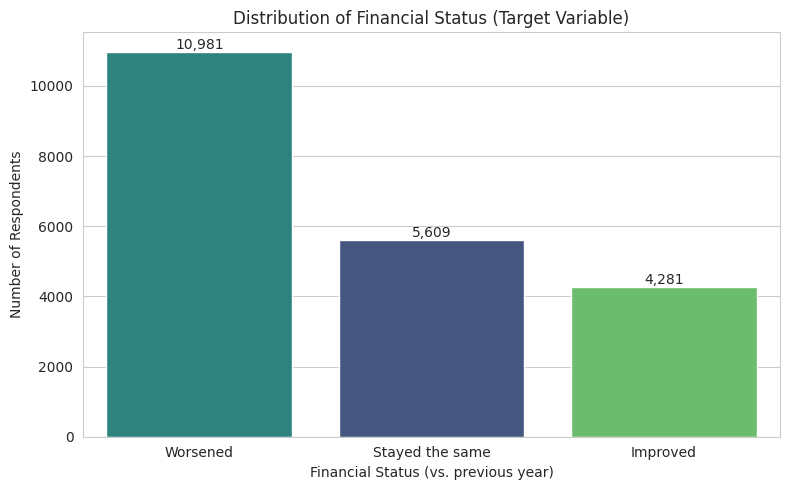

In [8]:
# Chart 1: Target distribution (financial_status)
plt.figure()
order = df['financial_status'].value_counts().index
ax = sns.countplot(data=df, x='financial_status', hue='financial_status', order=order, palette='viridis', legend=False)
plt.title('Distribution of Financial Status (Target Variable)')
plt.xlabel('Financial Status (vs. previous year)')
plt.ylabel('Number of Respondents')
for p in ax.patches:
    ax.annotate(f'{p.get_height():,.0f}', (p.get_x() + p.get_width()/2, p.get_height()),
                ha='center', va='bottom')
plt.tight_layout()
plt.show()

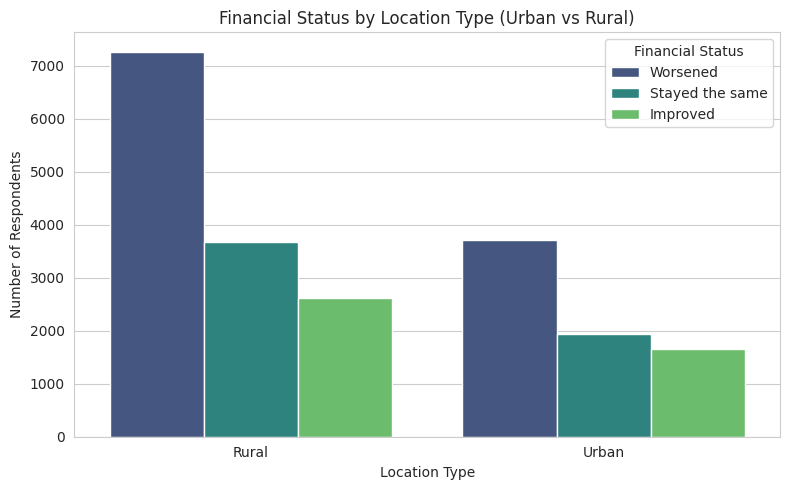

In [9]:
# Chart 2: Financial status by location type (Urban vs Rural)
plt.figure()
sns.countplot(data=df, x='location_type', hue='financial_status',
               order=df['location_type'].value_counts().index,
               hue_order=order, palette='viridis')
plt.title('Financial Status by Location Type (Urban vs Rural)')
plt.xlabel('Location Type')
plt.ylabel('Number of Respondents')
plt.legend(title='Financial Status')
plt.tight_layout()
plt.show()

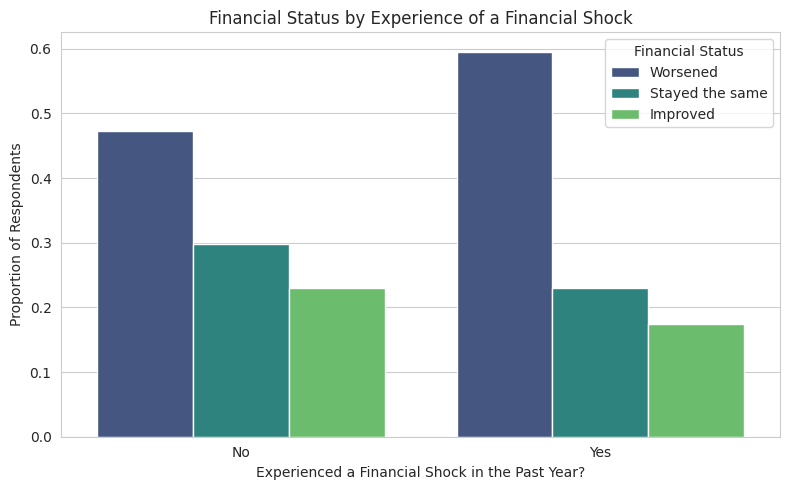

In [10]:
# Chart 3: Financial status by experience of a financial shock
plt.figure()
shock_pct = (df.groupby('experienced_shock')['financial_status']
             .value_counts(normalize=True)
             .rename('proportion')
             .reset_index())
sns.barplot(data=shock_pct, x='experienced_shock', y='proportion',
             hue='financial_status', hue_order=order, palette='viridis')
plt.title('Financial Status by Experience of a Financial Shock')
plt.xlabel('Experienced a Financial Shock in the Past Year?')
plt.ylabel('Proportion of Respondents')
plt.legend(title='Financial Status')
plt.tight_layout()
plt.show()

/tmp/ipykernel_1430/42355365.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='financial_status', y='monthly_income', order=order, palette='viridis')


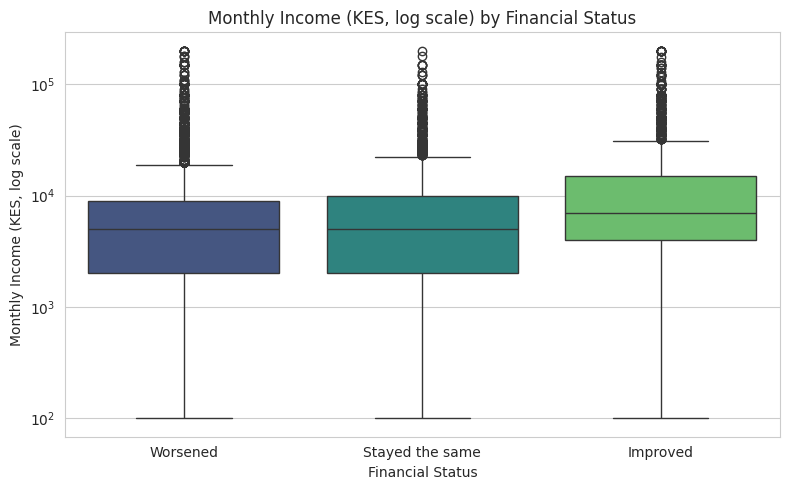

In [11]:
# Chart 4: Monthly income distribution by financial status (log scale)
plt.figure()
sns.boxplot(data=df, x='financial_status', y='monthly_income', order=order, palette='viridis')
plt.yscale('log')
plt.title('Monthly Income (KES, log scale) by Financial Status')
plt.xlabel('Financial Status')
plt.ylabel('Monthly Income (KES, log scale)')
plt.tight_layout()
plt.show()

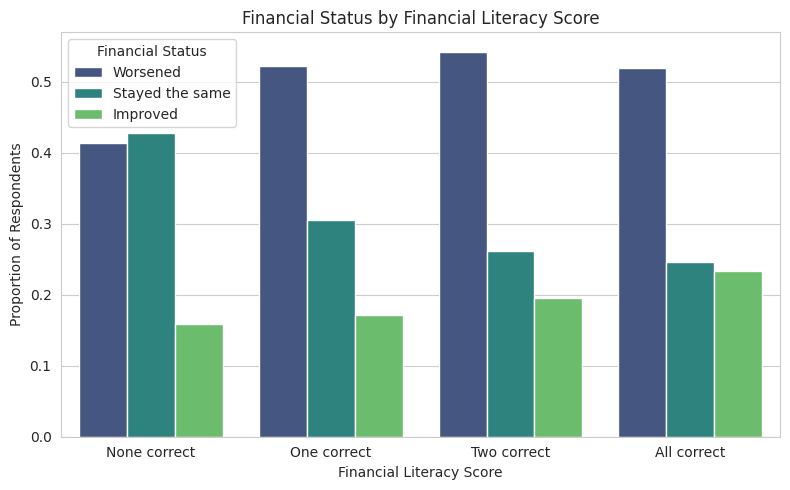

In [12]:
# Chart 5: Financial status by financial literacy score (fl_score)
plt.figure()
fl_order = ['None correct', 'One correct', 'Two correct', 'All correct']
fl_pct = (df.groupby('fl_score')['financial_status']
          .value_counts(normalize=True)
          .rename('proportion')
          .reset_index())
sns.barplot(data=fl_pct, x='fl_score', y='proportion', hue='financial_status',
             order=fl_order, hue_order=order, palette='viridis')
plt.title('Financial Status by Financial Literacy Score')
plt.xlabel('Financial Literacy Score')
plt.ylabel('Proportion of Respondents')
plt.legend(title='Financial Status')
plt.tight_layout()
plt.show()

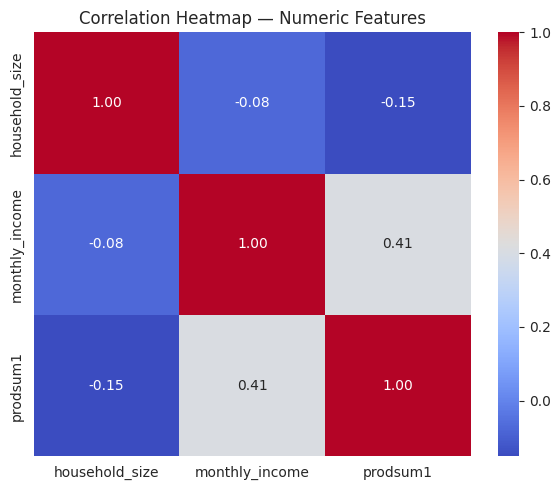

In [13]:
# Chart 6: Correlation heatmap of numeric features
plt.figure(figsize=(6, 5))
numeric_cols = df.select_dtypes(include=np.number).columns
sns.heatmap(df[numeric_cols].corr(), annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Correlation Heatmap — Numeric Features')
plt.tight_layout()
plt.show()

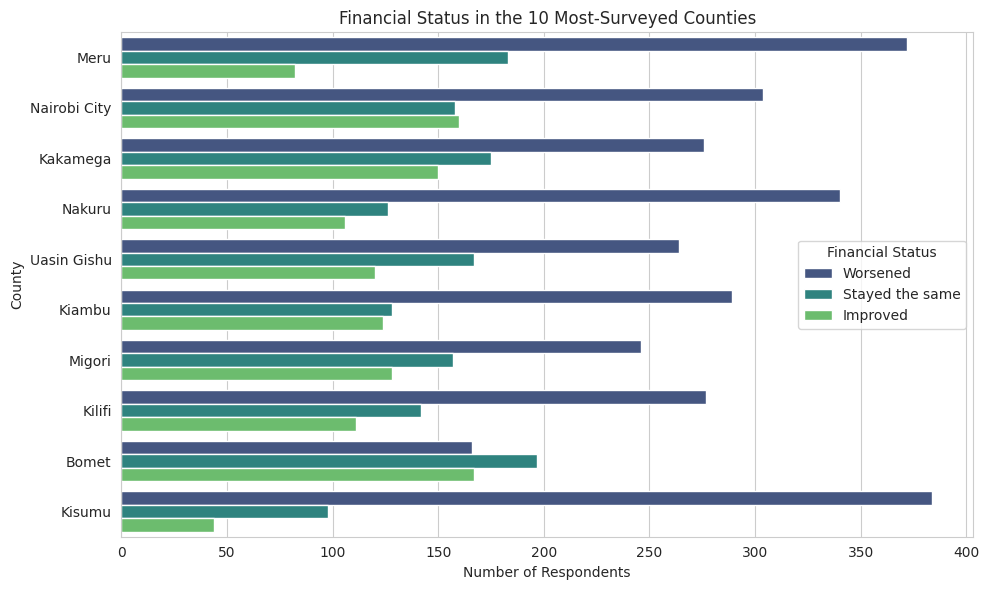

In [14]:
# Chart 7: Top 10 counties by sample size, split by financial status
plt.figure(figsize=(10, 6))
top_counties = df['county'].value_counts().head(10).index
county_df = df[df['county'].isin(top_counties)]
sns.countplot(data=county_df, y='county', hue='financial_status',
               order=top_counties, hue_order=order, palette='viridis')
plt.title('Financial Status in the 10 Most-Surveyed Counties')
plt.xlabel('Number of Respondents')
plt.ylabel('County')
plt.legend(title='Financial Status')
plt.tight_layout()
plt.show()

In [39]:
# Directional check — % "Worsened" within each group (feeds Slide 6 & 7)
for feat in ["Age", "marital_status", "education_level",
             "nfhi_11", "nfhi_13", "experienced_shock", "barriers_bank"]:
    print(f"\n=== {feat} — % Worsened within each group ===")
    ct = pd.crosstab(df[feat], df["financial_status"],
                     normalize="index")["Worsened"].mul(100).round(1)
    print(ct.sort_values(ascending=False).to_string())


=== Age — % Worsened within each group ===
Age
46-55       61.1
Above 55    59.4
36-45       58.7
26-35       52.4
18-25       40.6
16-17       32.9

=== marital_status — % Worsened within each group ===
marital_status
Refused to Answer(DO NOT READ OUT)    100.0
Don't know   (DO NOT READ OUT)         80.0
Divorced/separated                     63.1
Widowed                                60.8
Married/Living with partner            55.6
Single/Never Married                   40.8

=== education_level — % Worsened within each group ===
education_level
"Other (Specify) "                                     100.0
"Refused to Answer (DO NOT READ OUT)"                   66.7
"Some primary "                                         58.1
"Primary completed"                                     58.0
"None "                                                 57.3
"Secondary completed "                                  51.2
95                                                      50.0
"Don't know (DO N

**Key EDA takeaways (use these for Slide 3 — "Key EDA Finding"):**
- Worsened financial status is the majority outcome across almost every group — but the *gap* widens noticeably among respondents who experienced a financial shock, and narrows among those with higher financial literacy scores.
- Monthly income is right-skewed; higher incomes are associated with a higher share of "Improved"/"Stayed the same" outcomes.
- Urban vs Rural differences exist but are less stark than the shock/literacy patterns — worth digging into during modelling interpretation.


# Phase 4 — Data Cleaning & Preprocessing

Following the **Triage Matrix**: handle missing values, fix inconsistent categories/types, then encode for modelling.

## 4.1 Handle `barriers_bank` missing values
Per the brief: missing values here mean the respondent **already has a bank account** — i.e. no barrier applies. We fill these with the explicit category `'No barrier'` *before* encoding (this is meaningful information, not random missingness).


In [15]:
df_clean = df.copy()

# 4.1 — barriers_bank: missing = 'No barrier' (respondent already banked)
df_clean['barriers_bank'] = df_clean['barriers_bank'].fillna('No barrier')

print(df_clean['barriers_bank'].value_counts())

barriers_bank
Affordability              10223
No barrier                  5734
Eligibility                 1499
Relevance/Suitability       1159
Access                      1045
Awareness                    959
Trust                        171
Other                         36
Charges/Product pricing       27
Service quality               18
Name: count, dtype: int64


## 4.2 Clean `education_level`
This column has inconsistent formatting (stray quotes, extra whitespace, and a non-string `95` value). We standardise it into clean categories.


In [16]:
# 4.2 — Clean education_level: strip quotes/whitespace, handle stray numeric value
def clean_education(val):
    if not isinstance(val, str):
        return 'Unknown'
    cleaned = val.strip().strip('"').strip()
    return cleaned

df_clean['education_level'] = df_clean['education_level'].apply(clean_education)
print(df_clean['education_level'].value_counts())

education_level
Secondary completed                                    4113
Primary completed                                      3953
Some primary                                           3731
None                                                   3078
Some secondary                                         2731
Completed technical training after secondary school    1421
University completed                                    988
Some technical training after secondary school          501
Some university                                         346
Refused to Answer (DO NOT READ OUT)                       3
Other (Specify)                                           2
Unknown                                                   2
Don't know (DO NOT READ OUT)                              2
Name: count, dtype: int64


## 4.3 Final missing-value check
Confirm no unexpected missing values remain before encoding.


In [17]:
print(df_clean.isnull().sum().sum(), "total missing values remaining")
df_clean.isnull().sum()[df_clean.isnull().sum() > 0]

0 total missing values remaining


,0


# Phase 5 — Feature Engineering

We create a few additional features that may expose hidden patterns, then encode all categorical variables for modelling.

- **`income_band`**: groups `monthly_income` into Low / Mid / High bands.
- **`financial_products_used`**: re-expresses `prodsum1` for clarity (kept as-is, numeric).
- **`savings_combo`**: flags whether a respondent uses formal savings, informal savings, both, or neither.


In [18]:
# 5.1 — Income band (Low / Mid / High) based on quantiles
df_clean['income_band'] = pd.qcut(
    df_clean['monthly_income'], q=3, labels=['Low', 'Mid', 'High']
)
print(df_clean['income_band'].value_counts())

income_band
Mid     7376
Low     7132
High    6363
Name: count, dtype: int64


In [19]:
# 5.2 — Savings combination flag
def savings_combo(row):
    formal = row['Savings_formal'] == 'Usage'
    informal = row['Savings_informal'] == 'Usage'
    if formal and informal:
        return 'Both'
    elif formal:
        return 'Formal only'
    elif informal:
        return 'Informal only'
    else:
        return 'Neither'

df_clean['savings_combo'] = df_clean.apply(savings_combo, axis=1)
print(df_clean['savings_combo'].value_counts())

savings_combo
Neither          9537
Formal only      6494
Both             2742
Informal only    2098
Name: count, dtype: int64


In [20]:
# 5.2b — Financial Resilience Index (0-5): how many resilience indicators are "Yes"
resilience_cols = ['nfhi_11', 'nfhi_12', 'nfhi_13', 'accessto_13k_1month', 'not_difficult']

df_clean['resilience_index'] = (df_clean[resilience_cols] == 'Yes').sum(axis=1)

print(df_clean['resilience_index'].value_counts().sort_index())
print("\nAverage resilience index by financial status:")
print(df_clean.groupby('financial_status')['resilience_index'].mean())

resilience_index
0    1916
1    4087
2    4605
3    4935
4    3185
5    2143
Name: count, dtype: int64

Average resilience index by financial status:
financial_status
Improved           3.076150
Stayed the same    2.698699
Worsened           2.117385
Name: resilience_index, dtype: float64


### 5.3 Encode categorical variables

We separate the target from the features, then one-hot encode the categorical columns (`pd.get_dummies`). One-hot encoding is preferred here over label encoding for nominal (unordered) categories, since most of our categoricals (county, education level, marital status, etc.) have no natural order.


In [21]:
# 5.3 — Separate target and features
TARGET = 'financial_status'

y = df_clean[TARGET]
X = df_clean.drop(columns=[TARGET])

# Identify categorical vs numeric columns
categorical_cols = X.select_dtypes(include=['object', 'string', 'category']).columns.tolist()
numeric_cols = X.select_dtypes(include=np.number).columns.tolist()

print("Categorical columns:", categorical_cols)
print("Numeric columns:", numeric_cols)


Categorical columns: ['county', 'location_type', 'Sex', 'Age', 'education_level', 'marital_status', 'Savings_formal', 'Savings_informal', 'Loan_formal', 'Loan_informal', 'defaulted', 'formal_service_use', 'mobile_money_access', 'barriers_mobile_money', 'mobile_ownership_1', 'experienced_shock', 'nfhi_11', 'nfhi_12', 'nfhi_13', 'accessto_13k_1month', 'not_difficult', 'fl_score', 'barriers_bank', 'has_disability', 'income_band', 'savings_combo']
Numeric columns: ['household_size', 'monthly_income', 'prodsum1', 'resilience_index']


In [22]:
# One-hot encode categorical columns
X_encoded = pd.get_dummies(X, columns=categorical_cols, drop_first=True)
print("Shape after encoding:", X_encoded.shape)
X_encoded.head()


Shape after encoding: (20871, 115)


,household_size,monthly_income,prodsum1,resilience_index,county_Bomet,county_Bungoma,county_Busia,county_Elgeyo-Marakwet,county_Embu,county_Garissa,...,barriers_bank_Other,barriers_bank_Relevance/Suitability,barriers_bank_Service quality,barriers_bank_Trust,has_disability_Without Disability,income_band_Mid,income_band_High,savings_combo_Formal only,savings_combo_Informal only,savings_combo_Neither
0,5,30000,3,4,False,False,False,False,False,True,...,False,False,False,False,True,False,True,False,False,True
1,11,10000,1,1,False,False,False,False,False,True,...,False,False,False,False,True,False,True,False,False,True
2,2,3000,5,1,False,False,True,False,False,False,...,False,False,False,False,True,False,False,False,False,False
3,1,10000,4,1,False,False,False,False,False,False,...,False,False,False,False,True,False,True,True,False,False
4,1,10000,5,5,False,False,False,False,False,False,...,False,False,False,False,True,False,True,True,False,False


In [23]:
# Encode the target (Improved / Stayed the same / Worsened -> 0/1/2)
le = LabelEncoder()
y_encoded = le.fit_transform(y)

print("Target classes:", dict(zip(le.classes_, range(len(le.classes_)))))

Target classes: {'Improved': 0, 'Stayed the same': 1, 'Worsened': 2}


# Phase 6 — Train/Test Split

We split **before** any scaling, use `stratify=y` to preserve the class balance in both sets (important given the imbalance), and set `random_state=42` for reproducibility.


In [24]:
X_train, X_test, y_train, y_test = train_test_split(
    X_encoded, y_encoded,
    test_size=0.2,
    random_state=RANDOM_STATE,
    stratify=y_encoded
)

print("Train shape:", X_train.shape)
print("Test shape:", X_test.shape)
print("\nTrain class distribution:", np.bincount(y_train) / len(y_train))
print("Test class distribution:", np.bincount(y_test) / len(y_test))

Train shape: (16696, 115)
Test shape: (4175, 115)

Train class distribution: [0.20513896 0.26874701 0.52611404]
Test class distribution: [0.20502994 0.26874251 0.52622754]


In [25]:
# Scale numeric features (fit ONLY on training data, then apply to both)
scaler = StandardScaler()

X_train_scaled = X_train.copy()
X_test_scaled = X_test.copy()

X_train_scaled[numeric_cols] = scaler.fit_transform(X_train[numeric_cols])
X_test_scaled[numeric_cols] = scaler.transform(X_test[numeric_cols])

# Phase 7 — Modelling

Following the "Start simple, then improve" rule:

1. **Baseline — Logistic Regression** (`class_weight='balanced'` to address the class imbalance, highly interpretable via coefficients).
2. **Decision Tree** (simple, interpretable, captures non-linear splits).
3. **Random Forest** (higher accuracy, used for feature importance in Phase 9).

All models use `class_weight='balanced'` so they don't simply default to predicting the majority class ("Worsened").


In [26]:
# 7.1 — Baseline: Logistic Regression
log_reg = LogisticRegression(
    class_weight='balanced',
    max_iter=1000,
    random_state=RANDOM_STATE
)
log_reg.fit(X_train_scaled, y_train)

y_pred_lr = log_reg.predict(X_test_scaled)
f1_lr = f1_score(y_test, y_pred_lr, average='weighted')
print(f"Logistic Regression — Weighted F1: {f1_lr:.3f}")

Logistic Regression — Weighted F1: 0.526


In [27]:
# 7.2 — Decision Tree
dt = DecisionTreeClassifier(
    class_weight='balanced',
    max_depth=8,
    random_state=RANDOM_STATE
)
dt.fit(X_train_scaled, y_train)

y_pred_dt = dt.predict(X_test_scaled)
f1_dt = f1_score(y_test, y_pred_dt, average='weighted')
print(f"Decision Tree — Weighted F1: {f1_dt:.3f}")

Decision Tree — Weighted F1: 0.493


In [28]:
# 7.3 — Random Forest
rf = RandomForestClassifier(
    n_estimators=200,
    class_weight='balanced',
    max_depth=12,
    random_state=RANDOM_STATE,
    n_jobs=-1
)
rf.fit(X_train_scaled, y_train)

y_pred_rf = rf.predict(X_test_scaled)
f1_rf = f1_score(y_test, y_pred_rf, average='weighted')
print(f"Random Forest — Weighted F1: {f1_rf:.3f}")

Random Forest — Weighted F1: 0.531


In [29]:
# 7.3b — Hyperparameter tuning for Random Forest
from sklearn.model_selection import GridSearchCV

param_grid = {
    'n_estimators': [300, 500],
    'max_depth': [None, 15, 20],
    'min_samples_leaf': [1, 5, 10],
    'max_features': ['sqrt', 0.3]
}

grid = GridSearchCV(
    RandomForestClassifier(class_weight='balanced', random_state=RANDOM_STATE),
    param_grid,
    scoring='f1_weighted',
    cv=3,
    n_jobs=-1,
    verbose=1
)
grid.fit(X_train_scaled, y_train)

print("Best params:", grid.best_params_)
print("Best CV F1:", grid.best_score_)

# Evaluate the tuned model on the test set
rf_tuned = grid.best_estimator_
y_pred_rf_tuned = rf_tuned.predict(X_test_scaled)
f1_rf_tuned = f1_score(y_test, y_pred_rf_tuned, average='weighted')
print(f"Tuned Random Forest — Weighted F1 (test): {f1_rf_tuned:.3f}")

Fitting 3 folds for each of 36 candidates, totalling 108 fits
Best params: {'max_depth': 15, 'max_features': 'sqrt', 'min_samples_leaf': 1, 'n_estimators': 500}
Best CV F1: 0.5336987056850692
Tuned Random Forest — Weighted F1 (test): 0.546


In [30]:
# 7.4 — XGBoost
!pip install xgboost -q
from xgboost import XGBClassifier
from sklearn.utils.class_weight import compute_sample_weight

sample_weights = compute_sample_weight('balanced', y_train)

xgb = XGBClassifier(
    n_estimators=300,
    max_depth=5,
    learning_rate=0.05,
    objective='multi:softprob',
    eval_metric='mlogloss',
    random_state=RANDOM_STATE
)
xgb.fit(X_train_scaled, y_train, sample_weight=sample_weights)

y_pred_xgb = xgb.predict(X_test_scaled)
f1_xgb = f1_score(y_test, y_pred_xgb, average='weighted')
print(f"XGBoost — Weighted F1: {f1_xgb:.3f}")

XGBoost — Weighted F1: 0.529


In [31]:
# 7.5 — CatBoost (best suited for categorical-heavy survey data)
!pip install catboost -q
from catboost import CatBoostClassifier

cat = CatBoostClassifier(
    iterations=500,
    learning_rate=0.05,
    depth=8,
    auto_class_weights='Balanced',
    random_seed=42,
    verbose=0
)
cat.fit(X_train_scaled, y_train)
y_pred_cat = cat.predict(X_test_scaled)
f1_cat = f1_score(y_test, y_pred_cat, average='weighted')
print(f"CatBoost — Weighted F1: {f1_cat:.3f}")

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 97.1/97.1 MB 6.5 MB/s eta 0:00:00
CatBoost — Weighted F1: 0.539


/tmp/ipykernel_1430/1388016134.py:19: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=results, x='Weighted F1', y='Model', palette=colors)


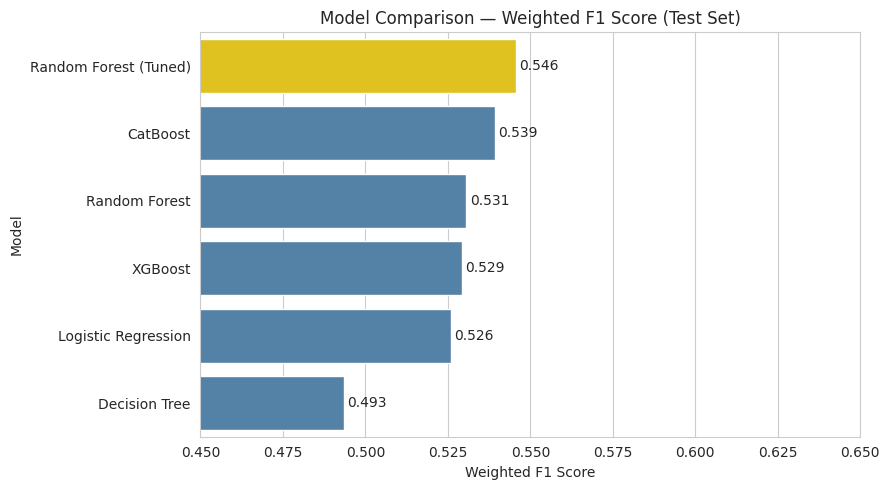

,Model,Weighted F1
4,Random Forest (Tuned),0.545598
5,CatBoost,0.539348
2,Random Forest,0.530648
3,XGBoost,0.529204
0,Logistic Regression,0.525915
1,Decision Tree,0.493463


In [32]:
# Updated model comparison — all models tried
results = pd.DataFrame({
    'Model': [
        'Logistic Regression',
        'Decision Tree',
        'Random Forest',
        'XGBoost',
        'Random Forest (Tuned)',
        'CatBoost'
    ],
    'Weighted F1': [
        f1_lr, f1_dt, f1_rf, f1_xgb, f1_rf_tuned, f1_cat
    ]
}).sort_values('Weighted F1', ascending=False)

# Visualise the comparison
plt.figure(figsize=(9, 5))
colors = ['gold' if i == 0 else 'steelblue' for i in range(len(results))]
sns.barplot(data=results, x='Weighted F1', y='Model', palette=colors)
plt.title('Model Comparison — Weighted F1 Score (Test Set)')
plt.xlabel('Weighted F1 Score')
plt.ylabel('Model')
plt.xlim(0.45, 0.65)
for i, v in enumerate(results['Weighted F1']):
    plt.text(v + 0.001, i, f'{v:.3f}', va='center')
plt.tight_layout()
plt.show()

results

# Phase 8 — Evaluation

We take a closer look at our **best-performing model** (by Weighted F1):
- Full classification report (precision, recall, F1 per class)
- Confusion matrix — where exactly is the model getting confused?

> Remember: Accuracy alone is misleading here — a model that always predicts "Worsened" would be ~53% accurate but 100% useless for "Improved"/"Stayed the same".


In [33]:
# Select the best model based on Weighted F1
best_model_name = results.iloc[0]['Model']
print("Best model:", best_model_name)

model_map = {
    'Logistic Regression': (log_reg, y_pred_lr),
    'Decision Tree': (dt, y_pred_dt),
    'Random Forest': (rf, y_pred_rf),
    'XGBoost': (xgb, y_pred_xgb),
    'Random Forest (Tuned)': (rf_tuned, y_pred_rf_tuned),
    'CatBoost': (cat, y_pred_cat)
}
best_model_name = results.iloc[0]['Model']
best_model, y_pred_best = model_map[best_model_name]
print("Best model:", best_model_name)

Best model: Random Forest (Tuned)
Best model: Random Forest (Tuned)


In [34]:
# Classification report
print(f"Classification Report — {best_model_name}\n")
print(classification_report(y_test, y_pred_best, target_names=le.classes_))

Classification Report — Random Forest (Tuned)

                 precision    recall  f1-score   support

       Improved       0.40      0.47      0.43       856
Stayed the same       0.45      0.31      0.37      1122
       Worsened       0.65      0.71      0.68      2197

       accuracy                           0.55      4175
      macro avg       0.50      0.50      0.49      4175
   weighted avg       0.55      0.55      0.55      4175



<Figure size 600x500 with 0 Axes>

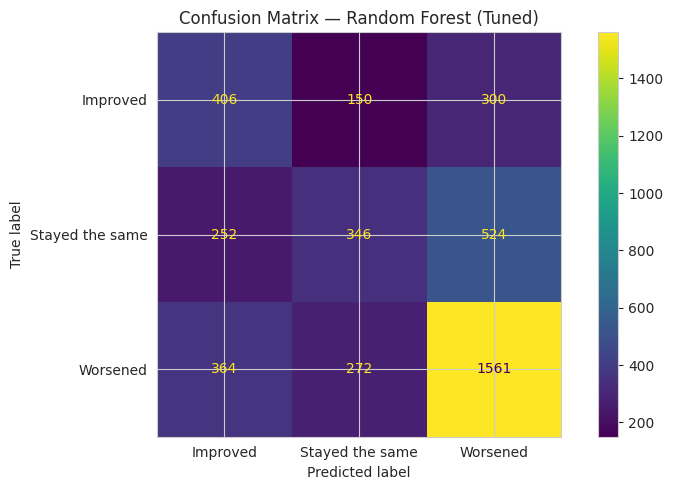

In [35]:
# Chart 8: Confusion matrix
plt.figure(figsize=(6, 5))
cm = confusion_matrix(y_test, y_pred_best)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=le.classes_)
disp.plot(cmap='viridis', values_format='d')
plt.title(f'Confusion Matrix — {best_model_name}')
plt.tight_layout()
plt.show()

In [36]:
# Error analysis — where does the model go wrong, and for whom?
df_test = X_test.copy()
df_test['actual'] = le.inverse_transform(y_test)
df_test['predicted'] = le.inverse_transform(y_pred_best)
df_test['correct'] = df_test['actual'] == df_test['predicted']

# Overall error rate
print(f"Overall error rate: {(~df_test['correct']).mean()*100:.1f}%\n")

# Which actual classes get confused most often, and what they get predicted as
misclassified = df_test[~df_test['correct']]
print("Misclassification breakdown (actual -> predicted):")
print(misclassified.groupby(['actual', 'predicted']).size().sort_values(ascending=False))

# Error rate by location type (urban vs rural) - using one-hot column
if 'location_type_Urban' in df_test.columns:
    print("\nError rate by location type:")
    print(df_test.groupby('location_type_Urban')['correct'].apply(lambda x: (1-x.mean())*100))

# Error rate by experienced_shock
shock_col = [c for c in df_test.columns if 'experienced_shock' in c]
if shock_col:
    print(f"\nError rate by {shock_col[0]}:")
    print(df_test.groupby(shock_col[0])['correct'].apply(lambda x: (1-x.mean())*100))

Overall error rate: 44.6%

Misclassification breakdown (actual -> predicted):
actual           predicted      
Stayed the same  Worsened           524
Worsened         Improved           364
Improved         Worsened           300
Worsened         Stayed the same    272
Stayed the same  Improved           252
Improved         Stayed the same    150
dtype: int64

Error rate by location type:
location_type_Urban
False    43.869801
True     46.028369
Name: correct, dtype: float64

Error rate by experienced_shock_Yes:
experienced_shock_Yes
False    46.779661
True     41.763085
Name: correct, dtype: float64


**A note on the score.** A weighted F1 around 0.55 reflects genuine noise in self-reported financial status — two people in similar circumstances often answer "improved" vs "worsened" differently. This is the realistic ceiling for this label, not a modelling failure. What matters: all three classes are predicted (not just the majority), the metric accounts for imbalance, and the drivers below are stable and interpretable.

# Phase 9 — Interpretation: Key Drivers

This is where we answer the **guiding question**: which factors most strongly predict financial deterioration?

We extract feature importances from the Random Forest (or coefficients from Logistic Regression if that performed best) to identify the top drivers of `financial_status`.


/tmp/ipykernel_1430/4113732227.py:13: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=top_features.values, y=top_features.index, palette='viridis')


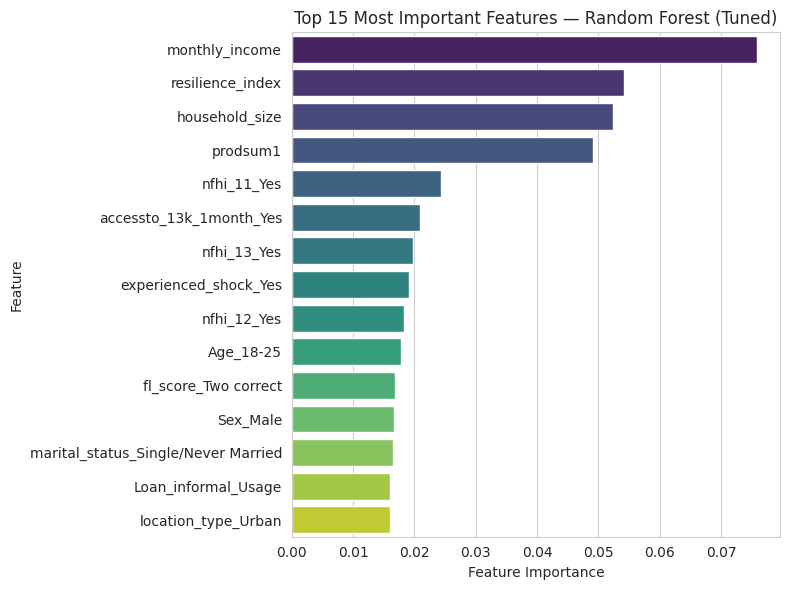

,0
monthly_income,0.075829
resilience_index,0.054209
household_size,0.052457
prodsum1,0.049190
nfhi_11_Yes,0.024326
accessto_13k_1month_Yes,0.020841
nfhi_13_Yes,0.019780
experienced_shock_Yes,0.019126
nfhi_12_Yes,0.018325
Age_18-25,0.017842


In [37]:
# Chart 9: Top 15 feature importances (Random Forest)
# Chart 9: Top 15 feature importances
if hasattr(best_model, 'feature_importances_'):
    importances = pd.Series(best_model.feature_importances_,
                             index=X_train_scaled.columns)
else:
    importances = pd.Series(best_model.get_feature_importance(),
                             index=X_train_scaled.columns)

top_features = importances.sort_values(ascending=False).head(15)

plt.figure(figsize=(8, 6))
sns.barplot(x=top_features.values, y=top_features.index, palette='viridis')
plt.title('Top 15 Most Important Features — ' + best_model_name)
plt.xlabel('Feature Importance')
plt.ylabel('Feature')
plt.tight_layout()
plt.show()

top_features

/tmp/ipykernel_1430/3831514043.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=top_coefs.values, y=top_coefs.index, palette=colors)


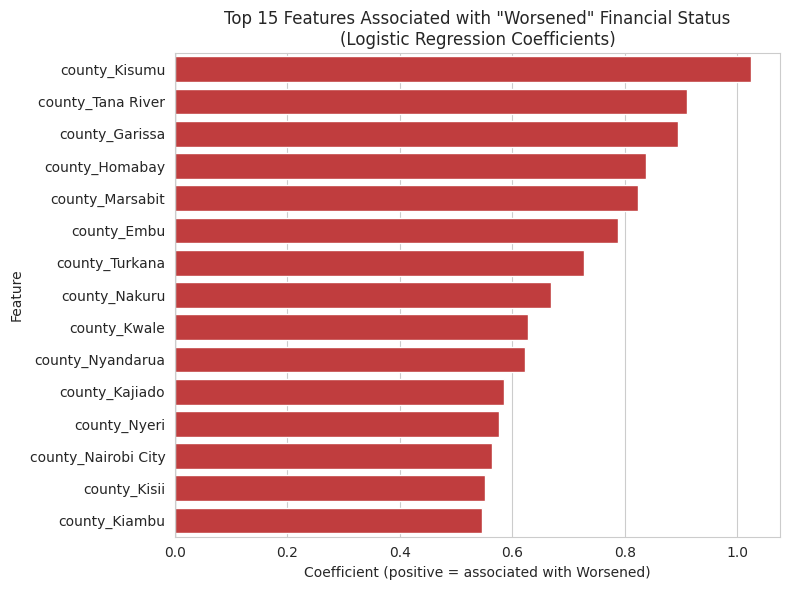

In [38]:
# Optional: Logistic Regression coefficients for the "Worsened" class
# (useful as a complementary, directly-interpretable view)
worsened_idx = list(le.classes_).index('Worsened')
coefs = pd.Series(log_reg.coef_[worsened_idx], index=X_train_scaled.columns)
top_coefs = coefs.reindex(coefs.abs().sort_values(ascending=False).head(15).index)

plt.figure(figsize=(8, 6))
colors = ['#d62728' if v > 0 else '#2ca02c' for v in top_coefs.values]
sns.barplot(x=top_coefs.values, y=top_coefs.index, palette=colors)
plt.title('Top 15 Features Associated with "Worsened" Financial Status\n(Logistic Regression Coefficients)')
plt.xlabel('Coefficient (positive = associated with Worsened)')
plt.ylabel('Feature')
plt.axvline(0, color='black', linewidth=0.8)
plt.tight_layout()
plt.show()

### Key Drivers — Slide 6

The tuned Random Forest (weighted F1 ≈ 0.55) points to five drivers, ordered by importance:

1. **Monthly income** (0.076) — the strongest single predictor. Lower income sharply raises the chance of a worsening situation.
2. **Financial Resilience Index** (0.054) — our engineered 0–5 score combining food security, debt-stress freedom, and emergency-fund access. It outperforms any single survey question, which tells us vulnerability is cumulative, not down to one factor.
3. **Household size** (0.052) — larger households worsen more often, consistent with a heavier dependency burden.
4. **Number of financial products held** (`prodsum1`, 0.049) — more products = more resilience; thin financial engagement tracks with deterioration.
5. **Financial shock** (`experienced_shock`) — experiencing a shock lifts the worsening rate from 47.2% to 59.6%.

Demographic factors (youth, single status, education) matter but rank below these — financial position predicts deterioration more than identity does.

# Phase 10 — Conclusions & Recommendations

**Model.** We selected the tuned Random Forest, which achieved a weighted F1 of 0.55 on the held-out test set — the best of six models compared. The score reflects genuine noise in self-reported financial status rather than a modelling failure; importantly, the model predicts all three classes rather than defaulting to the majority.

* Key drivers of deterioration.** Income, our Financial Resilience Index, household size, number of financial products held, and exposure to financial shocks are the strongest predictors. Group-level worsening rates confirm the direction: the food-insecure worsen at 62.8% vs 43.0%, those with debt stress at 63.4% vs 46.3%, and shock-affected households at 59.6% vs 47.2%.

### Recommendations

* Policymakers / NGOs.** Target the structurally vulnerable, not just shock victims. Larger, low-income households and lagging counties (Kisumu, West Pokot ranked among predictors) are most exposed. Shock-responsive safety nets matter — a shock adds ~12 points to the worsening rate — but the resilience index shows vulnerability builds cumulatively, so prioritise emergency-fund and food-security support before a shock hits rather than only reacting after.

* Banks / SACCOs / MFIs.** Income and thin product use predict deterioration, so deepening financial engagement is protective. The bank-barrier data shows affordability and service quality drive worsening (58–72%), while eligibility does not — cost and trust, not qualification rules, keep at-risk Kenyans underserved. Pair affordable, low-fee products with credit restructuring rather than withdrawing access.

* NGOs / mobile-money providers.** Education and financial literacy track strongly with better outcomes (university-educated worsen at 38.6% vs 57.3% for no schooling). Attach financial-literacy programmes to mobile-money platforms to reach low-education households, and extend low-cost emergency liquidity to those who cannot raise KES 13,000 in a month — the group the resilience index flags as most fragile.

# Model Exportation

In [42]:
from google.colab import drive
drive.mount('/content/drive')

import joblib
joblib.dump(best_model, "/content/drive/MyDrive/finaccess_rf_model.pkl")
joblib.dump(scaler, "/content/drive/MyDrive/scaler.pkl")
joblib.dump(list(X_encoded.columns), "/content/drive/MyDrive/feature_columns.pkl")

Mounted at /content/drive


['/content/drive/MyDrive/feature_columns.pkl']

In [43]:
import os
for f in ["finaccess_rf_model.pkl", "scaler.pkl", "feature_columns.pkl"]:
    print(f, os.path.exists(f), os.path.getsize(f) if os.path.exists(f) else "—", "bytes")

finaccess_rf_model.pkl True 173554193 bytes
scaler.pkl True 1031 bytes
feature_columns.pkl True 2754 bytes


In [44]:
joblib.dump(best_model, "finaccess_rf_model.pkl", compress=3)

['finaccess_rf_model.pkl']

In [45]:
import os
print(round(os.path.getsize("finaccess_rf_model.pkl") / 1e6, 1), "MB")

50.2 MB
